Simple Linear Regression: Simple Linear Regression (SLR) is a statistical method used to model the relationship between one independent variable (X) and one dependent variable (Y) by fitting a straight line to observed data.

𝑦=𝛽0+𝛽1𝑥+𝜖

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("house_prices_inr.csv")
df.head()

,Area,Price_INR
0,750,3194193
1,800,2502586
2,850,3969622
3,900,3588555
4,950,4021949


In [7]:
df.describe()

,Area,Price_INR
count,60.00000,6.000000e+01
mean,2225.00000,1.071367e+07
std,873.21246,6.872745e+06
min,750.00000,2.502586e+06
25%,1487.50000,5.778317e+06
50%,2225.00000,9.109538e+06
75%,2962.50000,1.409777e+07
max,3700.00000,3.938714e+07


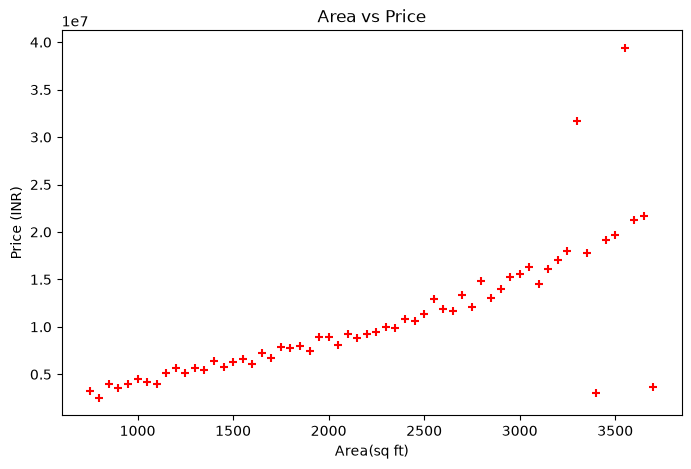

In [ ]:
plt.figure(figsize=(8,5))

plt.xlabel('Area(sq ft)')
plt.ylabel('Price (INR)')


plt.scatter(df['Area'], df['Price_INR'], color='red', marker='+')
plt.title("Area vs Price")
plt.show()

#this scale creates a problem -> not proportional

Split data into training and testing sets

In [9]:
X=df[['Area']]
y = df['Price_INR']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Taining set size:", X_train.shape[0])
print("Training price size:", y_train.shape[0])


Taining set size: 48
Training price size: 48


In [ ]:
model = linear_model.LinearRegression()

#Fit the model
model.fit(X_train, y_train)  #80% area, 80% price

#linear model successfully trained

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5910.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.6e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
#Predict on the test set
y_pred = model.predict(X_test)      # only passing the area
y_pred

array([ 1832400.74174528,  3309912.33691751, 12470484.22698537,
       15130005.09829539,  5673930.88919309, 17789525.96960541,
       11583977.26988203, 16016512.05539872,  5378428.57015864,
       18676032.92670875, 15425507.41732983, 16607516.69346762])

Evaluate model performance (R2 Score)

In [12]:
r2 = model.score(X_test, y_test)
print(f"R2 score on test set: {r2:.4f}")

R2 score on test set: 0.9624


Calculate key statistical metrics(MAE, MSE, RMSE)

In [13]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae: .2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  952250.86
MSE: 1343124400840.18
RMSE: 1158932.44


Manual Prediction calculation

In [ ]:
area = 2500
m = model.coef_[0]
b = model.intercept_
y_manual = m*area + b
print(f"Manual cal for area {area}: {y_manual}")
print(f"Model pred for area {area}: {model.predict([[area]])[0]:.2f}") # area is 2d thats why we are taking [0]

Manual cal for area 2500: 12174981.907950917
Model pred for area 2500: 12174981.91


d:\dataScience\vsCode\env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predict for array of values

In [16]:
new_areas = pd.read_csv("Area.csv")
new_areas.head()

,Area
0,950
1,1000
2,1859
3,948
4,1908


In [17]:
predicted_prices = model.predict(new_areas)
predicted_prices

array([3014410.01788307, 3309912.33691751, 8386642.17792931,
       3002589.92512169, 8676234.45058307, 3309912.33691751,
       9154948.20741887, 3900916.97498641, 5082926.25112419])

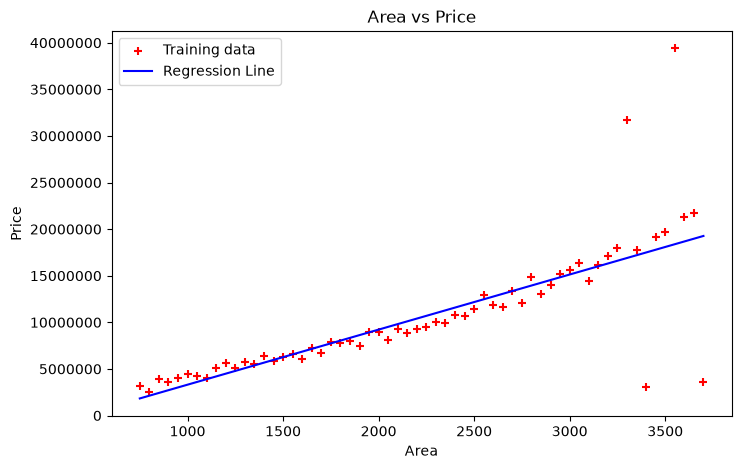

In [ ]:
plt.figure(figsize=(8,5))
plt.xlabel("Area")
plt.ylabel("Price")
#Disable scientific notation on y axis
plt.ticklabel_format(style='plain', axis='y')   # to get exact values in y axis and not e values
plt.scatter(df['Area'], df['Price_INR'], color='red', marker='+', label='Training data')
plt.plot(df['Area'], model.predict(df[['Area']]), color='blue', label='Regression Line')
plt.legend()

plt.title("Area vs Price")
plt.show()

Simple Linear Regression

Problem Statement

You are given a dataset `exam_scores.csv` containing the number of study hours and corresponding exam scores for 50 students. Your task is to build a Simple Linear Regression model to predict the exam score based on the number of study hours.

You should:
- Load and explore the data
- Visualize the data
- Split the data into training and testing sets
- Train a simple linear regression model
- Evaluate the model using R², MAE, MSE, and RMSE
- Visualize the regression line
- Predict the exam score for a student who studied 8 hours

In [3]:
df2 = pd.read_csv("exam_scores.csv")
df2.head()

,study_hours,exam_score
0,7.66,89.68
1,6.43,83.24
2,1.91,64.71
3,4.98,75.93
4,6.24,84.79


In [4]:
df2.describe()

,study_hours,exam_score
count,50.000000,50.000000
mean,5.205400,74.214400
std,1.820888,13.396587
min,1.040000,38.390000
25%,4.112500,65.005000
50%,5.245000,74.605000
75%,6.237500,83.795000
max,9.770000,108.450000


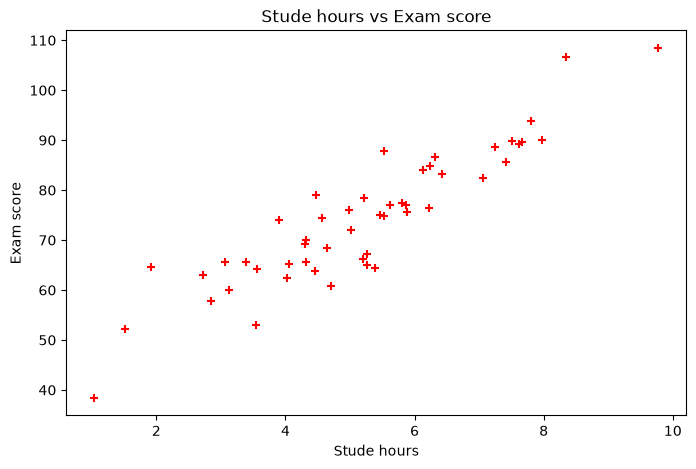

In [5]:
plt.figure(figsize=(8,5))

plt.xlabel('Stude hours')
plt.ylabel('Exam score')


plt.scatter(df2['study_hours'], df2['exam_score'], color='red', marker='+')
plt.title("Stude hours vs Exam score")
plt.show()

In [6]:
X=df2[['study_hours']]
y = df2[['exam_score']]

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Taining set size:", X_train.shape[0])
print("Training price size:", y_train.shape[0])

Taining set size: 40
Training price size: 40


In [7]:
model = linear_model.LinearRegression()

#Fit the model
model.fit(X_train, y_train)  #80% area, 80% price

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[6.41]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[41.09]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [8]:
#Predict on the test set
y_pred = model.predict(X_test)      # only passing the area
y_pred

array([[86.3826401 ],
       [63.80272661],
       [69.76844239],
       [70.40991721],
       [74.90024091],
       [80.41692432],
       [74.45120854],
       [94.65766522],
       [74.90024091],
       [59.31240291]])

In [9]:
r2 = model.score(X_test, y_test)
print(f"R2 score on test set: {r2:.4f}")

R2 score on test set: 0.7129


In [10]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae: .2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  7.07
MSE: 61.55
RMSE: 7.85


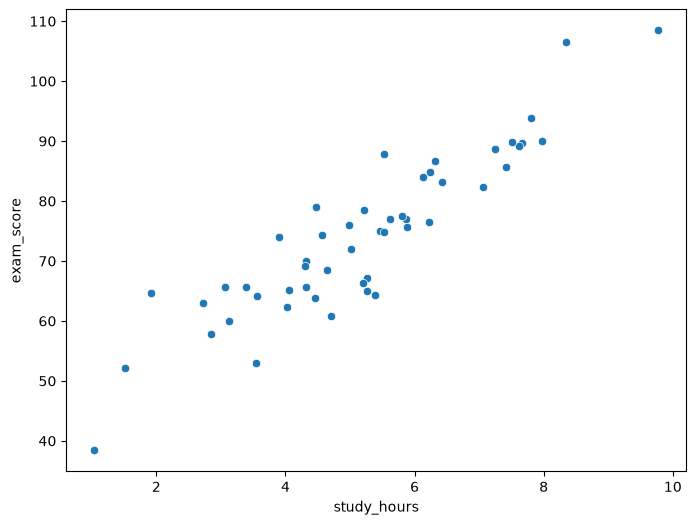

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df2,x=df2['study_hours'], y=df2['exam_score'])
plt.show()

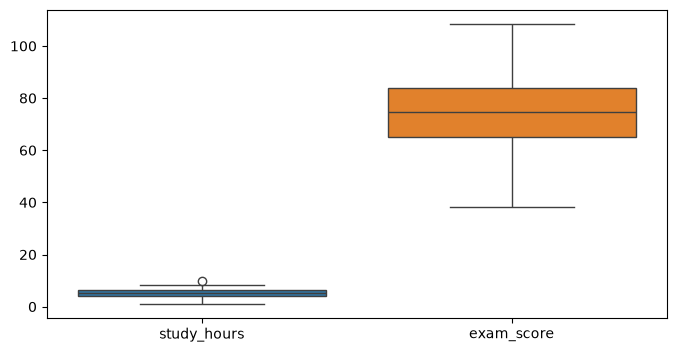

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df2[['study_hours', 'exam_score']])
plt.show()

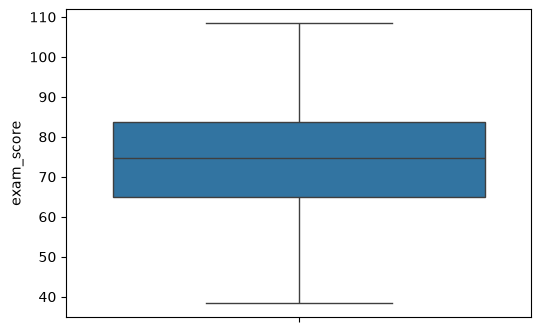

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df2, y='exam_score')
plt.show()